# Modelo 2 — demonstração

**Um data center, 168 candidatos, 5 finalistas, 1 escolhido.** Este notebook percorre o funil
inteiro num caso real.

O desenho e as decisões estão em `07_modelo2_construcao.ipynb`.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DADOS = RAIZ / "dados-modelo-impacto" / "raw" / "controles-rf"

cand = pd.read_csv(DADOS / "candidatos_avaliados_rf.csv")
par  = pd.read_csv(DADOS / "pareamento_controle_rf.csv")
print(f"{cand.site_id.nunique()} campi · {len(cand)} finalistas avaliados · {len(par)} pares fechados")

15 campi · 71 finalistas avaliados · 15 pares fechados


In [2]:
CAMPUS = "ascenty-vinhedo"   # troque por qualquer site_id da lista abaixo
print("campi disponíveis:", ", ".join(sorted(cand.site_id.unique())))

campi disponíveis: angonap-fortaleza, ascenty-hortolandia, ascenty-jundiai, ascenty-maracanau, ascenty-osasco, ascenty-paulinia, ascenty-sumare, ascenty-vinhedo, clickip-manaus, equinix-santana-parnaiba, everest-goiania, hostdime-joao-pessoa, scala-sgigsm01, scala-spoapa01, scala-tambore


## 1. O funil, em números

In [3]:
g = cand[cand.site_id == CAMPUS].sort_values("posicao_final_rf")
alvo = par[par.site_id == CAMPUS].iloc[0]

print(f"data center : {CAMPUS}  ({alvo.municipio}/{alvo.uf})")
print(f"coordenada  : {alvo.lat:.4f}, {alvo.lon:.4f}")
print(f"ano da obra : {int(alvo.ano_inicio_obra)}\n")
print(f"{'grade de candidatos':<44}{7 * 24:>6}")
print(f"{'sobreviveram aos filtros':<44}{int(alvo.n_candidatos_validos):>6}")
print(f"{'avaliados pelo classificador (finalistas)':<44}{len(g):>6}")
print(f"{'escolhido':<44}{1:>6}")

data center : ascenty-vinhedo  (Vinhedo/SP)
coordenada  : -23.0700, -47.0119
ano da obra : 2019

grade de candidatos                            168
sobreviveram aos filtros                        20
avaliados pelo classificador (finalistas)        5
escolhido                                        1


## 2. Os 5 finalistas, lado a lado

In [4]:
cols = ["site_id_controle", "dist_ao_tratamento_km", "municipio",
        "l1_mapbiomas", "l1_rf", "qualidade_rf", "escolhido"]
print(g[cols].to_string(index=False))

        site_id_controle  dist_ao_tratamento_km  municipio  l1_mapbiomas    l1_rf qualidade_rf  escolhido
ctrl-ascenty-vinhedo-p02                   28.0   Campinas      0.273312 0.131596    aceitavel       True
ctrl-ascenty-vinhedo-p01                   20.0   Campinas      0.249694 0.236028         ruim      False
ctrl-ascenty-vinhedo-p04                   40.0 Jaguariúna      0.336807 0.263263         ruim      False
ctrl-ascenty-vinhedo-p03                   40.0   Pedreira      0.299146 0.292849         ruim      False
ctrl-ascenty-vinhedo-p05                   16.0   Campinas      0.359831 0.332861         ruim      False


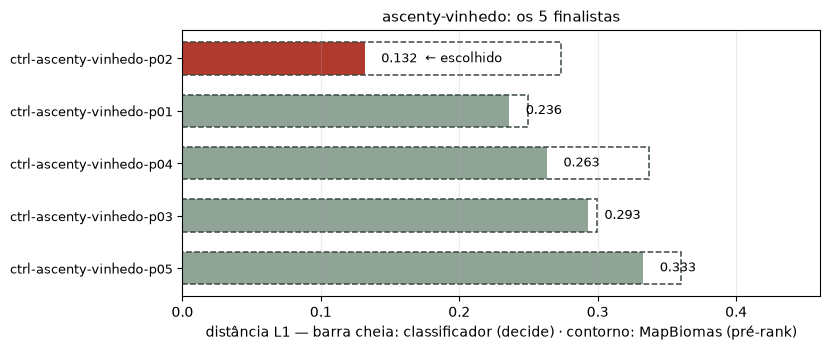

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
y = np.arange(len(g))[::-1]
cores = np.where(g.escolhido, "#B03A2E", "#8FA396")
ax.barh(y, g.l1_rf, color=cores, height=.62)
ax.barh(y, g.l1_mapbiomas, color="none", edgecolor="#3A4A40", height=.62, ls="--", lw=1.1)
for yi, (_, r) in zip(y, g.iterrows()):
    marca = "  ← escolhido" if r.escolhido else ""
    ax.text(r.l1_rf + .012, yi, f"{r.l1_rf:.3f}{marca}", va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(g.site_id_controle, fontsize=9)
ax.set_xlabel("distância L1 — barra cheia: classificador (decide) · contorno: MapBiomas (pré-rank)")
ax.set_title(f"{CAMPUS}: os 5 finalistas", fontsize=11)
ax.set_xlim(0, g[["l1_rf", "l1_mapbiomas"]].to_numpy().max() * 1.28)
ax.grid(axis="x", alpha=.25)
plt.tight_layout(); plt.show()

Repare que o **contorno tracejado** (MapBiomas) e a **barra cheia** (classificador) não
ordenam igual. O pré-ranqueamento serve só para cortar o custo — quem decide é o classificador.

## 3. Onde eles estão no mapa

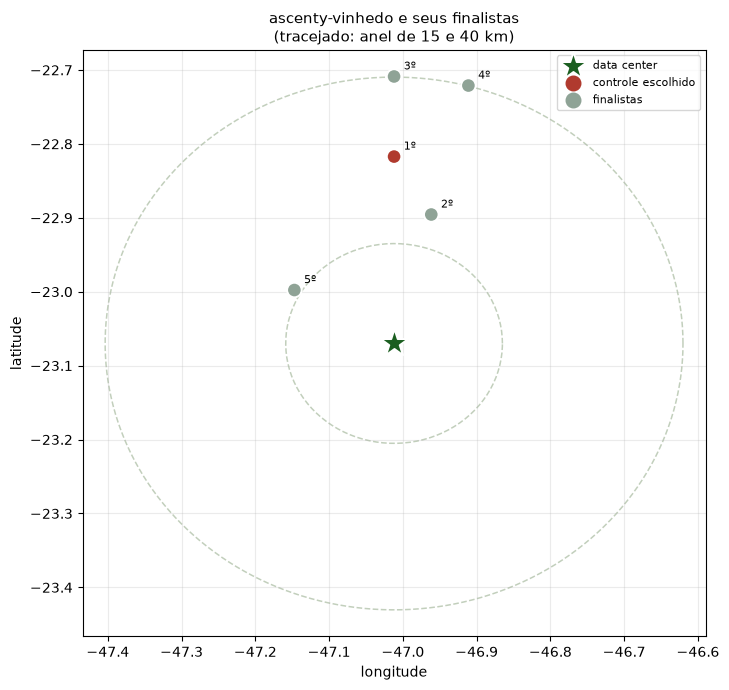

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 7))
for raio in (15, 40):
    a = np.linspace(0, 2 * np.pi, 200)
    dlat = raio / 111.0
    dlon = raio / (111.0 * np.cos(np.radians(alvo.lat)))
    ax.plot(alvo.lon + dlon * np.cos(a), alvo.lat + dlat * np.sin(a),
            c="#C2CFBC", lw=1.1, ls="--", zorder=1)

ax.scatter(g.lon, g.lat, s=110, c=np.where(g.escolhido, "#B03A2E", "#8FA396"),
           edgecolors="white", linewidths=1.4, zorder=3)
for _, r in g.iterrows():
    ax.annotate(f"{int(r.posicao_final_rf)}º", (r.lon, r.lat), fontsize=8,
                xytext=(7, 5), textcoords="offset points")
ax.scatter([alvo.lon], [alvo.lat], marker="*", s=430, c="#1B5E20",
           edgecolors="white", linewidths=1.4, zorder=4, label="data center")
ax.scatter([], [], c="#B03A2E", s=110, label="controle escolhido")
ax.scatter([], [], c="#8FA396", s=110, label="finalistas")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{CAMPUS} e seus finalistas\n(tracejado: anel de 15 e 40 km)", fontsize=11)
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=.25); ax.set_aspect("equal", "datalim")
plt.tight_layout(); plt.show()

## 4. O par que entra no estudo

In [7]:
venc = g[g.escolhido].iloc[0]
print(f"  tratamento : {alvo.site_id:<32} {alvo.lat:>10.4f}, {alvo.lon:.4f}")
print(f"  controle   : {venc.site_id_controle:<32} {venc.lat:>10.4f}, {venc.lon:.4f}")
print(f"  distância  : {venc.dist_ao_tratamento_km:.0f} km")
print(f"  L1 (RF)    : {venc.l1_rf:.3f}   →  {venc.qualidade_rf}")
print(f"  município  : {venc.municipio}/{venc.uf}  ({venc.metodo_municipio})")
print()
print("É deste par que sai uma linha do achado: a conversão medida no anel do tratamento")
print("MENOS a conversão medida no mesmo anel do controle. Repetido em 20 campi, vira o")
print("teste de sinal de 18/20 (p=0,0002).")

  tratamento : ascenty-vinhedo                    -23.0700, -47.0119
  controle   : ctrl-ascenty-vinhedo-p02           -22.8172, -47.0119
  distância  : 28 km
  L1 (RF)    : 0.132   →  aceitavel
  município  : Campinas/SP  (municipio_vizinho_microrregiao_ibge)

É deste par que sai uma linha do achado: a conversão medida no anel do tratamento
MENOS a conversão medida no mesmo anel do controle. Repetido em 20 campi, vira o
teste de sinal de 18/20 (p=0,0002).
